## Import LIBS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

## Load dataset

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

Training Shape: (60000, 28, 28)
Testing Shape: (10000, 28, 28)


## EDA

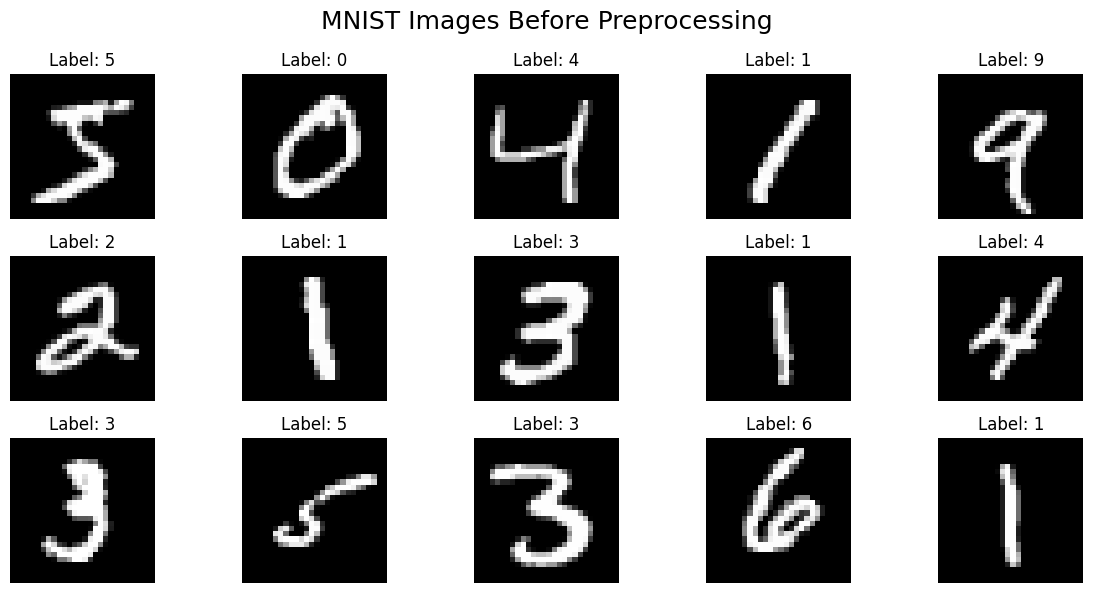

In [4]:
plt.figure(figsize=(12,6))
for i in range(15):
    plt.subplot(3,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("MNIST Images Before Preprocessing", fontsize=18)
plt.tight_layout()
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

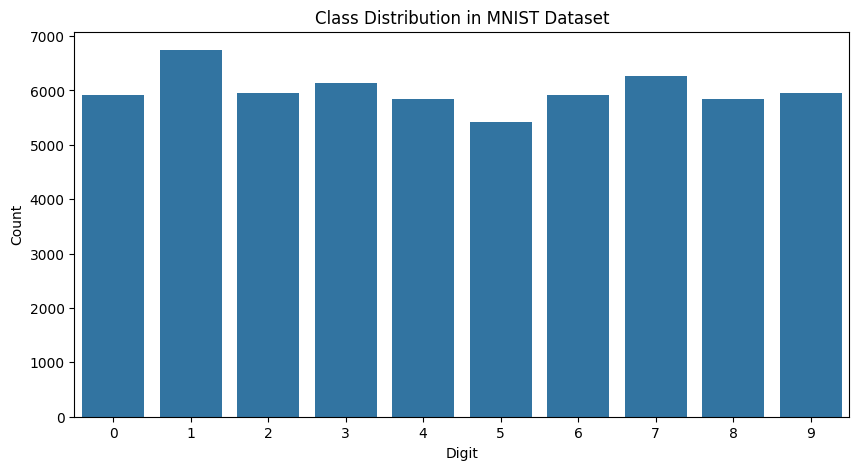

In [5]:
plt.figure(figsize=(10,5))
sns.countplot(x=y_train)
plt.title("Class Distribution in MNIST Dataset")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show

## PREPROCESSING

### Normalize

In [6]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

### reshape

In [7]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

### One-hot encoding

In [8]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("After Reshape:", x_train.shape)

After Reshape: (60000, 28, 28, 1)


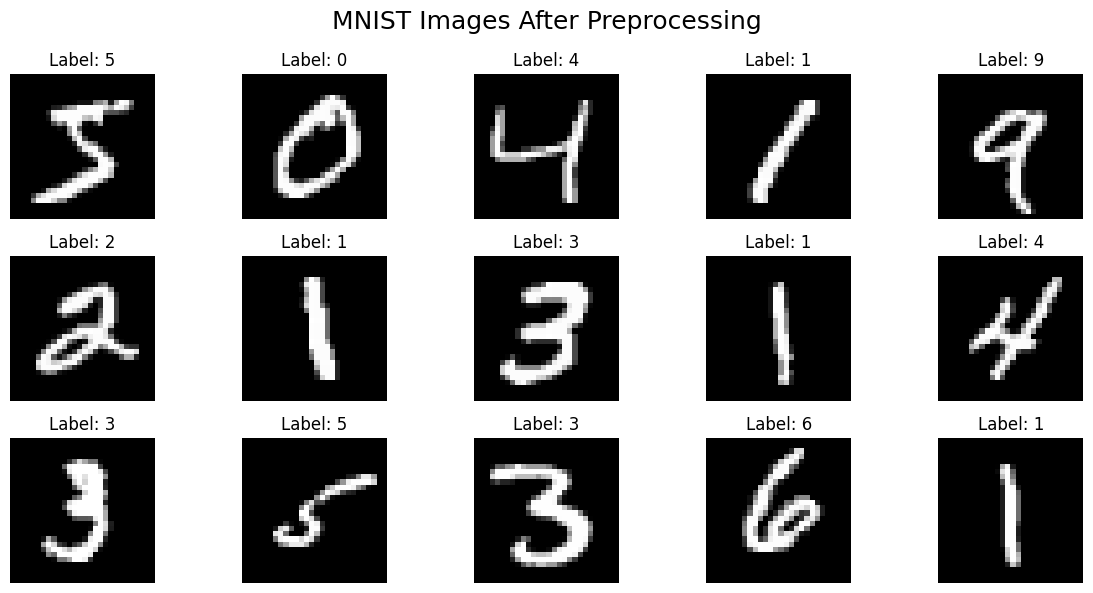

In [9]:
plt.figure(figsize=(12,6))
for i in range(15):
    plt.subplot(3,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("MNIST Images After Preprocessing", fontsize=18)
plt.tight_layout()
plt.show()

## Model before optimizar

In [10]:
model_before = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model_before.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_before.summary()

c:\Users\Habiba Elboraii\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history_before = model_before.fit(
    x_train,
    y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9391 - loss: 0.2048 - val_accuracy: 0.9755 - val_loss: 0.0843
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9797 - loss: 0.0677 - val_accuracy: 0.9806 - val_loss: 0.0636
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9865 - loss: 0.0450 - val_accuracy: 0.9841 - val_loss: 0.0528
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9898 - loss: 0.0322 - val_accuracy: 0.9816 - val_loss: 0.0651
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9930 - loss: 0.0226 - val_accuracy: 0.9859 - val_loss: 0.0521


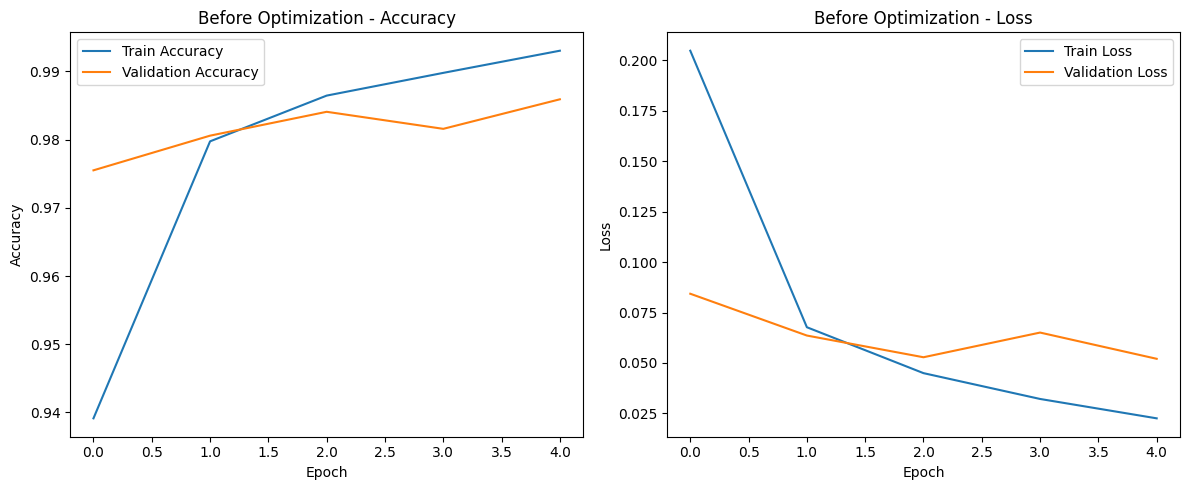

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_before.history['accuracy'], label='Train Accuracy')
plt.plot(history_before.history['val_accuracy'], label='Validation Accuracy')
plt.title('Before Optimization - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_before.history['loss'], label='Train Loss')
plt.plot(history_before.history['val_loss'], label='Validation Loss')
plt.title('Before Optimization - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

### Model after Optimaziar

In [13]:
model_after = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_after.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_after.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,200,010 (4.58 MB)

 Trainable params: 1,199,946 (4.58 MB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
history_after = model_after.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8993 - loss: 0.3306 - val_accuracy: 0.9794 - val_loss: 0.0695
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9603 - loss: 0.1338 - val_accuracy: 0.9841 - val_loss: 0.0544
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9706 - loss: 0.0974 - val_accuracy: 0.9849 - val_loss: 0.0532
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9756 - loss: 0.0791 - val_accuracy: 0.9866 - val_loss: 0.0469
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9788 - loss: 0.0706 - val_accuracy: 0.9893 - val_loss: 0.0430
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9817 - loss: 0.0607 - val_accuracy: 0.9858 - val_loss: 0.0523
Epoch 7/10
552/750 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9830 - loss: 0.0518

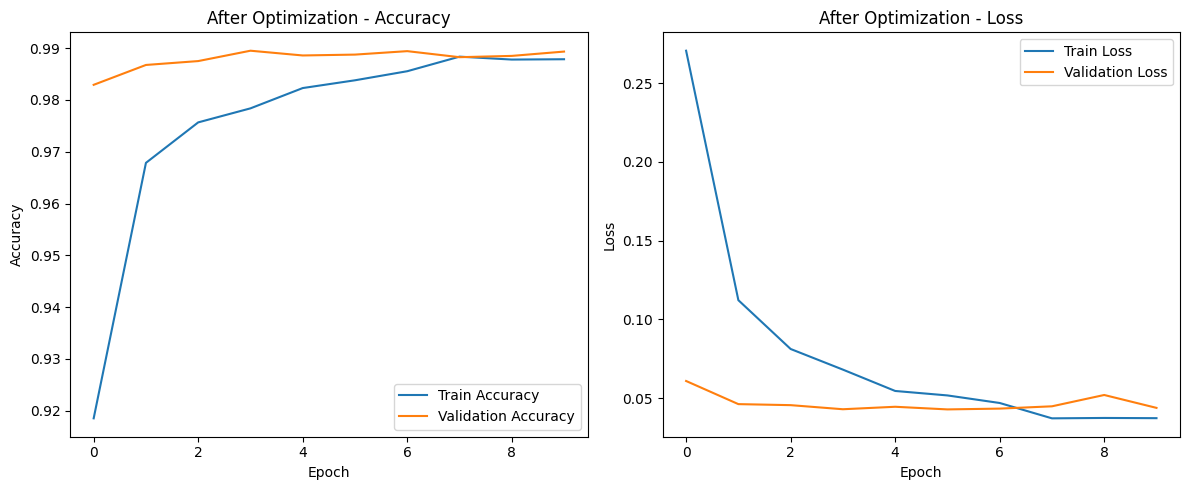

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_after.history['accuracy'], label='Train Accuracy')
plt.plot(history_after.history['val_accuracy'], label='Validation Accuracy')
plt.title('After Optimization - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_after.history['loss'], label='Train Loss')
plt.plot(history_after.history['val_loss'], label='Validation Loss')
plt.title('After Optimization - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Comparison

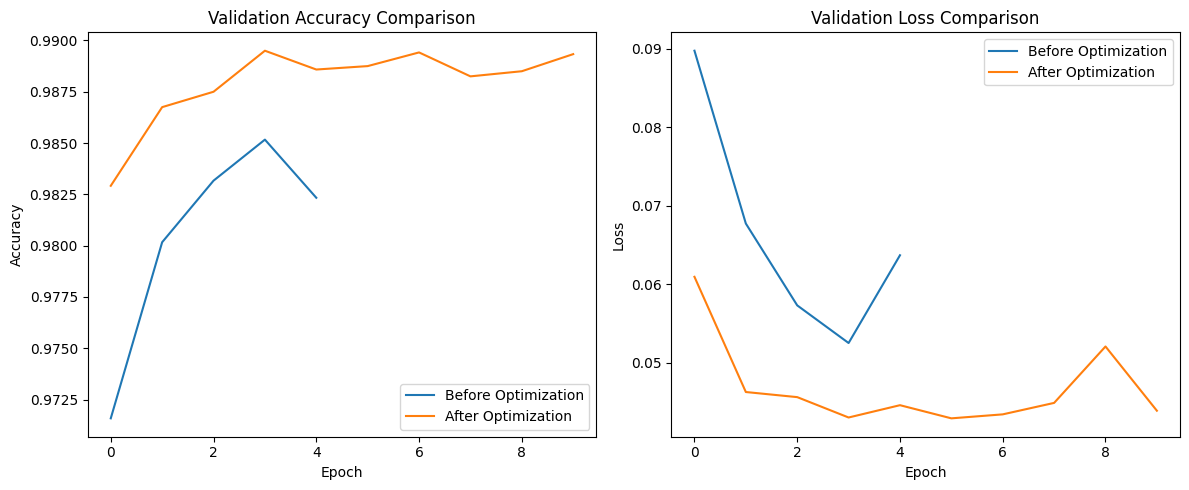

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_before.history['val_accuracy'], label='Before Optimization')
plt.plot(history_after.history['val_accuracy'], label='After Optimization')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_before.history['val_loss'], label='Before Optimization')
plt.plot(history_after.history['val_loss'], label='After Optimization')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## EVALUATION

In [ ]:
loss_before, acc_before = model_before.evaluate(x_test, y_test_cat)
loss_after, acc_after = model_after.evaluate(x_test, y_test_cat)

print("\nBefore Optimization Accuracy:", acc_before)
print("After Optimization Accuracy:", acc_after)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9841 - loss: 0.0507
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9898 - loss: 0.0413

Before Optimization Accuracy: 0.9840999841690063
After Optimization Accuracy: 0.989799976348877


## PREDICTIONS

In [ ]:
y_pred = model_after.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


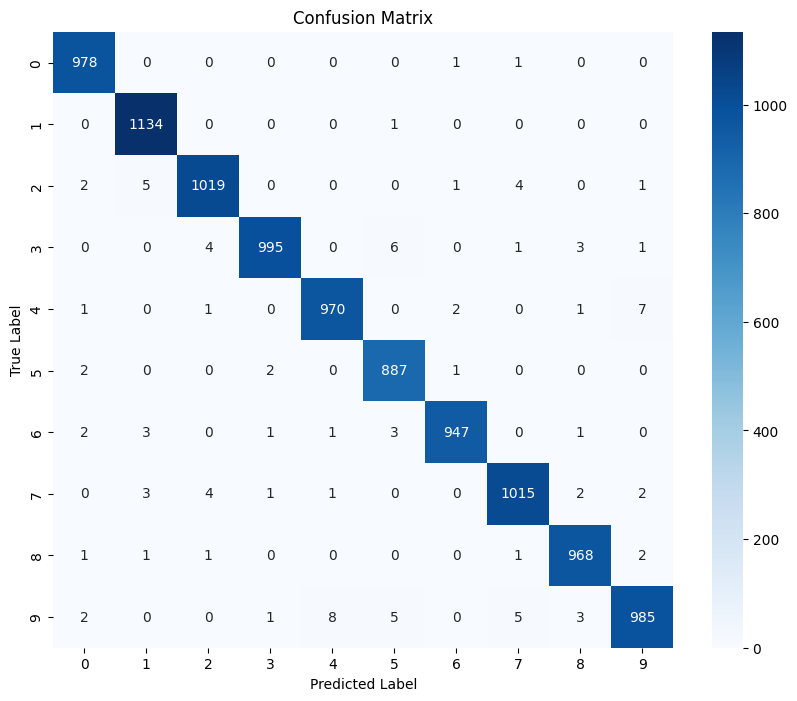

In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



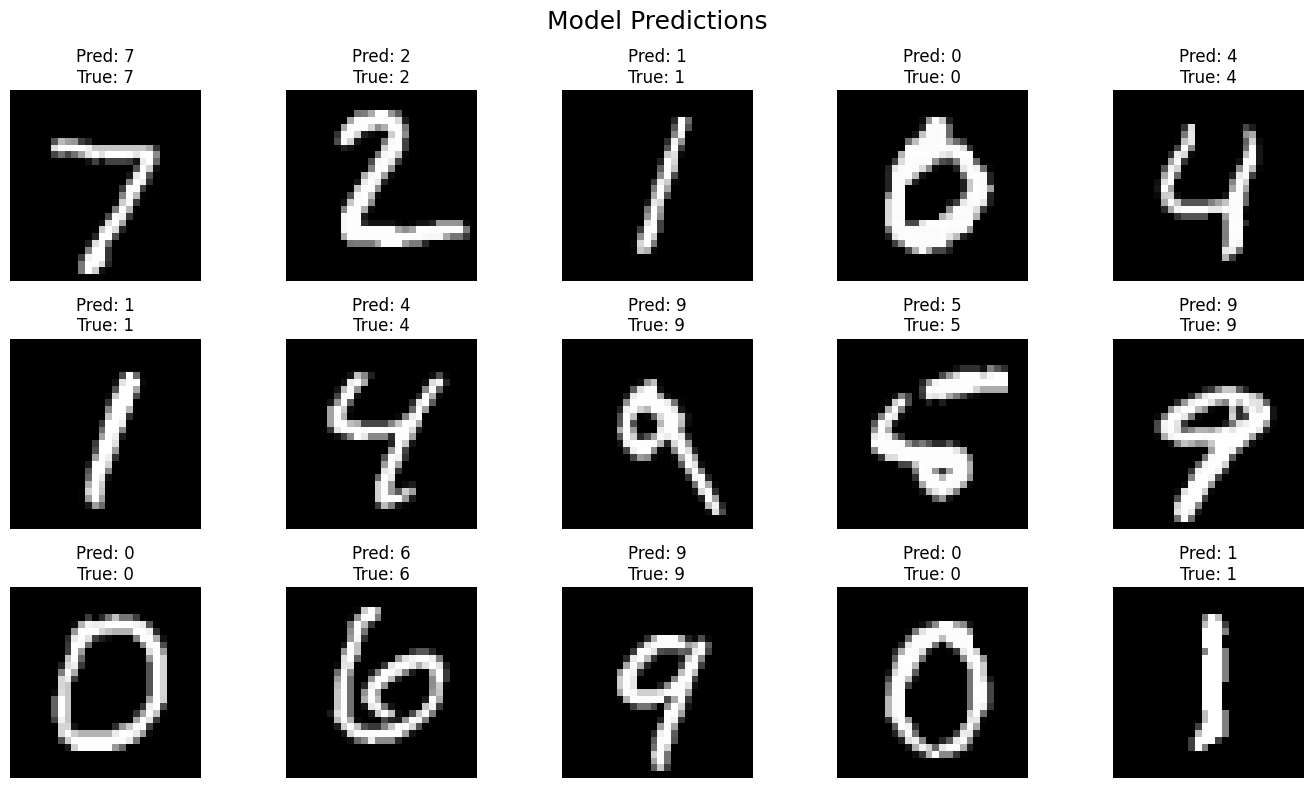

In [ ]:
plt.figure(figsize=(14,8))
for i in range(15):
    plt.subplot(3,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred_classes[i]}\nTrue: {y_test[i]}")
    plt.axis('off')

plt.suptitle('Model Predictions', fontsize=18)
plt.tight_layout()
plt.show()

## GUI

In [ ]:
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk
import numpy as np
from tensorflow.keras.models import load_model

In [ ]:
model = model_after


In [ ]:
def predict_image():
    file_path = filedialog.askopenfilename()

    if file_path:
        # Open image
        img = Image.open(file_path).convert('L')
        img = img.resize((28, 28))

        # Preprocessing
        img_array = np.array(img)
        img_array = 255 - img_array
        img_array = img_array / 255.0
        img_array = img_array.reshape(1, 28, 28, 1)

        # Prediction
        prediction = model.predict(img_array)
        predicted_class = np.argmax(prediction)
        confidence = np.max(prediction) * 100

        # Display image
        display_img = Image.open(file_path)
        display_img = display_img.resize((200, 200))

        photo = ImageTk.PhotoImage(display_img)

        image_label.config(image=photo)
        image_label.image = photo

        # Show result
        result_label.config(
            text=f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%"
        )

In [ ]:
root = tk.Tk()
root.title("MNIST CNN Classifier")
root.geometry("500x600")
root.configure(bg="#1e1e2f")

In [ ]:
title = tk.Label(
    root,
    text="MNIST CNN Classifier",
    font=("Arial", 24, "bold"),
    bg="#1e1e2f",
    fg="white"
)
title.pack(pady=20)

In [ ]:
image_label = tk.Label(root, bg="#1e1e2f")
image_label.pack(pady=20)

In [ ]:
result_label = tk.Label(
    root,
    text="Upload an Image",
    font=("Arial", 18),
    bg="#1e1e2f",
    fg="#00ffcc"
)
result_label.pack(pady=20)

In [ ]:
upload_btn = tk.Button(
    root,
    text="Upload Image",
    command=predict_image,
    font=("Arial", 16, "bold"),
    bg="#00b894",
    fg="white",
    padx=20,
    pady=10,
    borderwidth=0,
    cursor="hand2"
)
upload_btn.pack(pady=20)

In [ ]:
root.mainloop()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
